In [1]:
import numpy as np
from astropy.table import Table
from astropy.table import join
from astropy.table import vstack
from astropy.table import Column

from astropy.io import fits
import pandas as pd
from astropy.cosmology import Planck18

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')
from matplotlib.colors import LogNorm
import seaborn as sns

import warnings
from astropy.units import UnitsWarning

warnings.simplefilter('ignore', UnitsWarning)

In [2]:
base = '/pscratch/sd/v/vtorresg/cosmic-web/edr'

### Mass and env

In [79]:
ls = []
for zone in range(20):
    temp = Table.read(f'{base}/probabilities/zone_{zone:02d}_probability.fits.gz')
    # temp.add_column(Column([zone]*len(temp), name='ZONE'))
    ls.append(temp)

t_edr = vstack(ls)
len(t_edr)

657306

In [3]:
t = Table.read('/global/cfs/cdirs/desi/public/edr/vac/edr/stellar-mass-emline/v1.0/edr_galaxy_stellarmass_lineinfo_v1.0.fits')
t_sub = t['TARGETID', 'SED_MASS', 'Z', 'ZERR', ].copy()

score = np.array(t_sub['ZERR'])

order = np.lexsort((score, t_sub['TARGETID']))
t_sorted = t_sub[order]

tid = np.array(t_sorted['TARGETID'])
keep = np.ones(len(t_sorted), dtype=bool)
keep[1:] = tid[1:] != tid[:-1]
t_best = t_sorted[keep]

In [32]:
t_all = join(t_edr, t_best, keys='TARGETID', join_type='inner')
df = t_all.to_pandas()

In [33]:
pcols = ['PVOID', 'PSHEET', 'PFILAMENT', 'PKNOT']

df[pcols] = df[pcols].apply(pd.to_numeric, errors='coerce')
higher_col = df[pcols].idxmax(axis=1)

col_to_class = {'PVOID': 'Void', 
                'PSHEET': 'Sheet',
                'PFILAMENT': 'Filament',
                'PKNOT': 'Knot'}

df['ENV'] = higher_col.map(col_to_class)
df['P_MAX'] = df[pcols].max(axis=1)

In [34]:
df.head()

,TARGETID,TRACERTYPE,PVOID,PSHEET,PFILAMENT,PKNOT,ZONE,SED_MASS,ZERR,ENV,P_MAX
0,39627728013496446,b'LRG',0.05,0.40,0.55,0.0,9,3.641130e+11,0.000150,Filament,0.55
1,39627728013497219,b'LRG',0.17,0.55,0.28,0.0,9,1.569004e+11,0.000087,Sheet,0.55
2,39627728017687857,b'ELG',0.69,0.29,0.02,0.0,9,7.495882e+09,0.000117,Void,0.69
3,39627728017688475,b'LRG',0.04,0.73,0.23,0.0,9,2.039452e+11,0.000062,Sheet,0.73
4,39627728017688942,b'LRG',0.75,0.24,0.01,0.0,9,1.182719e+11,0.000030,Void,0.75


In [35]:
bgs = df[df['TRACERTYPE'] == b'BGS_ANY']
elg = df[df['TRACERTYPE'] == b'ELG']
lrg = df[df['TRACERTYPE'] == b'LRG']
qso = df[df['TRACERTYPE'] == b'QSO']

In [54]:
dfs = {'BGS': bgs, 'LRG': lrg, 'ELG': elg, 'QSO': qso}
ENV_ORDER = ['Void', 'Sheet', 'Filament', 'Knot']

In [71]:
xbins = np.arange(10.0, 13.21, 0.15)
xcenters = 0.5 * (xbins[:-1] + xbins[1:])

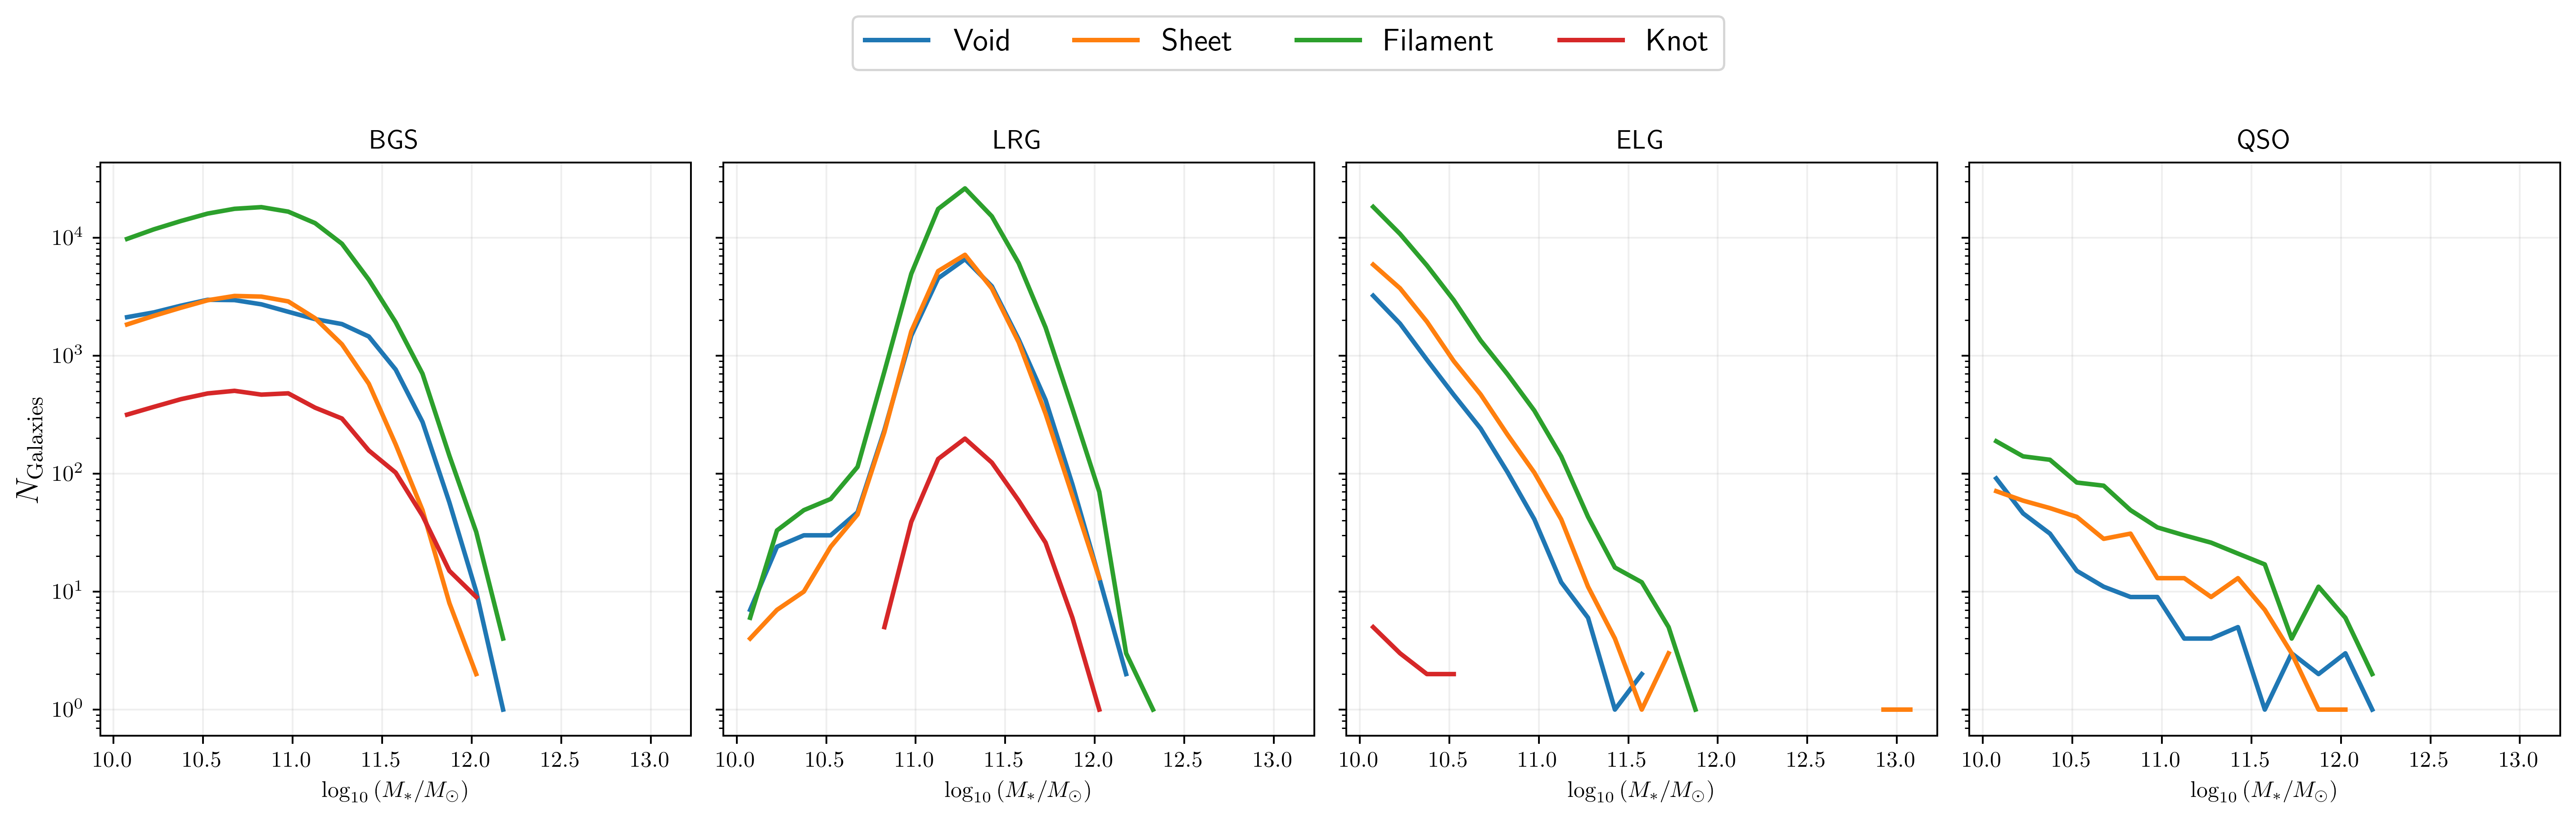

In [75]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (label, df_) in zip(axes, dfs.items()):
    d = df_.copy()

    d = d[np.isfinite(d['SED_MASS'])]
    # d = d[d['SED_MASS'] > 0]
    d['LOGM'] = np.log10(d['SED_MASS'].to_numpy())

    for env in ENV_ORDER:
        de = d[d['ENV'] == env]
        counts, _ = np.histogram(de['LOGM'], bins=xbins)

        y = counts.astype(float)
        y[y == 0] = np.nan
        # y[counts < 2] = np.nan
        ax.plot(xcenters, y, label=env, lw=2.0)#, marker='o', markersize=2.5)

    ax.set_yscale('log')
    ax.grid(alpha=0.2)
    ax.set_title(label)
    ax.set_xlabel(r'$\log_{10} \left( M_*/M_\odot \right)$')


axes[0].set_ylabel(r'$N_{\mathrm{Galaxies}}$', fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, frameon=True,
           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.89])
plt.savefig('./plots/mass_bins.png', dpi=360)
plt.show()

### Mass and $r$

In [4]:
ls = []
for zone in range(20):
    temp = Table.read(f'{base}/classification/zone_{zone:02d}_classified.fits.gz')
    ls.append(temp)

t_edr = vstack(ls)
len(t_edr)

131461200

In [5]:
t_edr['R'] = (t_edr['NDATA'] - t_edr['NRAND']) / (t_edr['NDATA'] + t_edr['NRAND'])

In [6]:
t_all = join(t_edr, t_best, keys='TARGETID', join_type='inner')
df = t_all.to_pandas()

In [7]:
df.head()

,TARGETID,RANDITER,ISDATA,NDATA,NRAND,TRACER_ID,TRACERTYPE,R,SED_MASS,Z,ZERR
0,39627728013496446,54,True,9,14,255,b'LRG',-0.217391,3.641130e+11,0.664478,0.00015
1,39627728013496446,22,True,16,10,255,b'LRG',0.230769,3.641130e+11,0.664478,0.00015
2,39627728013496446,15,True,10,11,255,b'LRG',-0.047619,3.641130e+11,0.664478,0.00015
3,39627728013496446,45,True,10,13,255,b'LRG',-0.130435,3.641130e+11,0.664478,0.00015
4,39627728013496446,19,True,13,7,255,b'LRG',0.300000,3.641130e+11,0.664478,0.00015


In [8]:
df['LOGM'] = np.log10(df['SED_MASS'])

In [18]:
d = df[df['TRACERTYPE'] == b'BGS_ANY'].copy()
d.shape

(23832200, 12)

In [19]:
z_bins = [(0.01, 0.16),
          (0.16, 0.31),
          (0.31, 0.45),
          (0.45, 0.60)]

In [38]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
quartile_labels = [r'$Q_1$', r'$Q_2$', r'$Q_3$', r'$Q_4$']

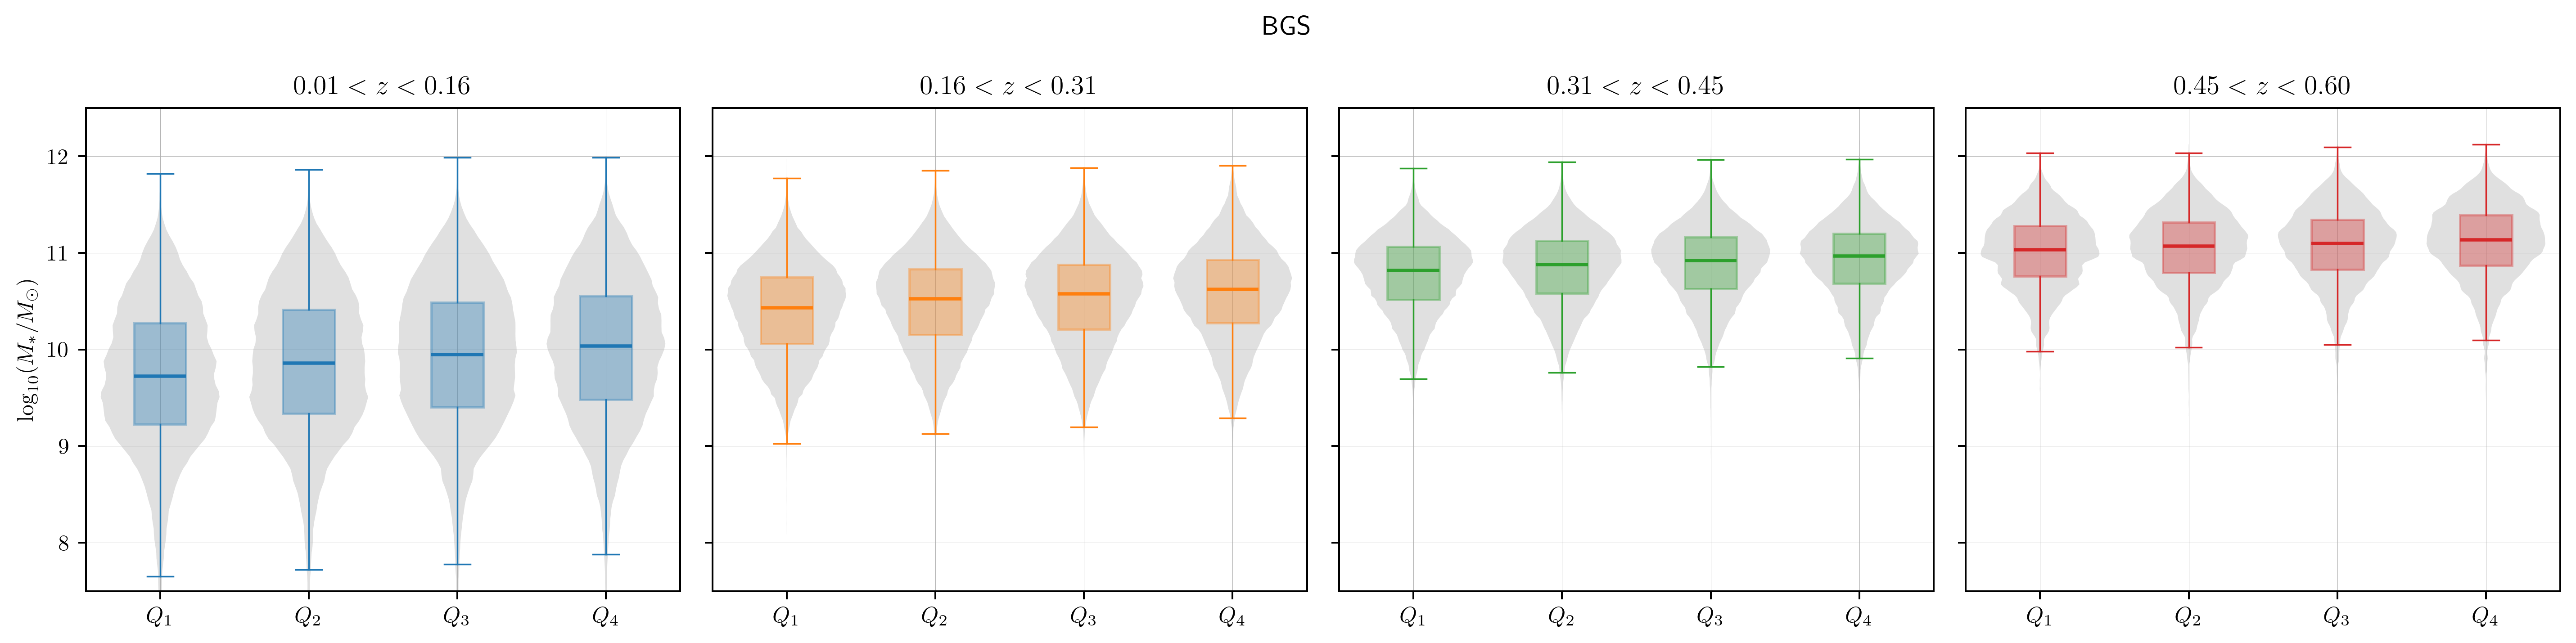

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
axes = axes.ravel()

for i, ((zmin, zmax), ax) in enumerate(zip(z_bins, axes)):
    
    color = default_colors[i % len(default_colors)]
    dz = d[(d['Z'] >= zmin) & (d['Z'] < zmax)].copy()

    dz['R_quartile'] = pd.qcut(dz['R'], 4, labels=quartile_labels, duplicates='drop')

    data_by_q = []
    valid_labels = []

    for qlab in quartile_labels:
        vals = dz.loc[dz['R_quartile'] == qlab, 'LOGM'].dropna().to_numpy()
        if len(vals) > 0:
            data_by_q.append(vals)
            valid_labels.append(qlab)

    positions = np.arange(1, len(data_by_q) + 1)

    vp = ax.violinplot(data_by_q, positions=positions, widths=0.8,
                       showmeans=False, showmedians=False, showextrema=False)

    for body in vp['bodies']:
        body.set_facecolor('lightgray')
        # body.set_edgecolor('gray')
        body.set_alpha(0.7)

    bp = ax.boxplot(data_by_q, positions=positions, widths=0.35,
                    patch_artist=True, showfliers=False)

    for box in bp['boxes']:
        # box.set(facecolor='steelblue', edgecolor='black', alpha=0.35)
        box.set(facecolor=color, edgecolor=color, alpha=0.35)

    for median in bp['medians']:
        # median.set(color='black', linewidth=1)
        median.set(color=color, linewidth=1.5)

    for whisker in bp['whiskers']:
        whisker.set(color=color, linewidth=0.7)

    for cap in bp['caps']:
        cap.set(color=color, linewidth=0.7)

    ax.set_title(rf'${zmin:.2f} < z < {zmax:.2f}$')
    ax.set_xticks(positions)
    ax.set_xticklabels(valid_labels)
    ax.grid(lw=0.2)
    ax.set_ylim(7.5,12.5)

axes[0].set_ylabel(r'$\log_{10}(M_*/M_\odot)$')

fig.suptitle('BGS')
plt.tight_layout()
plt.savefig('./plots/mass_quart.png', dpi=360, bbox_inches='tight')
plt.show()